# SAM Audio Preliminary Test

In [1]:
import torch
print(f'PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')
import numpy
print(f'numpy: {numpy.__version__}')
import laion_clap
print('laion_clap: OK')
from sam_audio import SAMAudio, SAMAudioProcessor
print('SAM-Audio: SUCCESS!')

/teamspace/studios/this_studio/anatolian-SAM/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


PyTorch: 2.11.0+cu130, CUDA: True
numpy: 1.26.4


/teamspace/studios/this_studio/anatolian-SAM/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/teamspace/studios/this_studio/anatolian-SAM/.venv/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.11.0+cu130)
    Python  3.10.19 (you have 3.11.15)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more d

laion_clap: OK


/teamspace/studios/this_studio/anatolian-SAM/.venv/lib/python3.11/site-packages/imagebind/data.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


SAM-Audio: SUCCESS!


In [2]:
import os
from huggingface_hub import login
from dotenv import load_dotenv

load_dotenv()

login(token=os.getenv("HF_TOKEN"))

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## Load SAM Audio Model (Base)

In [3]:
import torch
from sam_audio import SAMAudio, SAMAudioProcessor

MODEL_ID = "facebook/sam-audio-base"  # base model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SAMAudio.from_pretrained(MODEL_ID).eval()

# Use fp16 on GPU to cut VRAM roughly in half (3090 supports fp16 well)
model = model.to(device=device, dtype=torch.float16).eval()

processor = SAMAudioProcessor.from_pretrained(MODEL_ID)

print("Device:", device)
print("Sampling rate:", processor.audio_sampling_rate)

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 29746.84it/s]
/teamspace/studios/this_studio/anatolian-SAM/.venv/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


/teamspace/studios/this_studio/anatolian-SAM/.venv/lib/python3.11/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 64417.64it/s]
/teamspace/studios/this_studio/anatolian-SAM/.venv/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Fetching 8 files: 100%|███████

Device: cuda
Sampling rate: 48000


## Load Dataset

In [4]:
from anatolian_sam.mixed_dataloader import get_audio_dataloader
from IPython.display import Audio

target_sr = int(processor.audio_sampling_rate)

dataset, eval_loader = get_audio_dataloader(
    jsonl_path="../data/mixed_metadata.jsonl",
    data_base_path="/teamspace/studios/turkish-music/anatolian-SAM/data/mixed",
    target_sr=target_sr,
    batch_size=1,
    shuffle=False,
)

Loaded 720 audio tuples from mixed_metadata.jsonl


In [7]:
for batch in eval_loader:
    # The dataloader already formatted these as a list of tensors for the processor
    mixture_wavs = batch["mixture_wavs"]
    prompts = batch["prompts"]

    print("Original mixture")
    display(Audio(mixture_wavs[0].numpy(), rate=target_sr))

    print("Original target")
    display(Audio(batch["target_wavs"][0].numpy(), rate=target_sr))

    # Process the batch
    inputs = processor(
        audios=mixture_wavs,
        descriptions=prompts,
    )

    inputs = inputs.to(device)

    # 3. Run inference using PyTorch Autocast to manage FP16 safety automatically
    with torch.inference_mode():
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            result = model.separate(inputs)

    # Extract the first item in the batch to test
    target_np = result.target[0].detach().float().cpu().numpy()

    print(f"Evaluated Prompt: '{prompts[0]}'")
    display(Audio(target_np, rate=target_sr))

    break

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Original mixture


Original target


Evaluated Prompt: 'turkish flute'


In [8]:
import matplotlib.pyplot as plt

def plot_waveform(wav, sr, title="Waveform", max_seconds=15):
    """
    wav: Tensor [C, T] or [T]
    sr: sample rate (int)
    """
    if isinstance(wav, torch.Tensor):
        w = wav.detach().cpu()
    else:
        w = torch.tensor(wav)

    if w.ndim == 1:
        w = w.unsqueeze(0)

    # limit duration for readability
    max_samples = int(sr * max_seconds)
    w = w[:, :max_samples]

    t = torch.arange(w.shape[1]) / sr

    plt.figure(figsize=(14, 3))
    for c in range(w.shape[0]):
        plt.plot(t, w[c].numpy(), label=f"ch{c}")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    if w.shape[0] > 1:
        plt.legend()
    plt.tight_layout()
    plt.show()


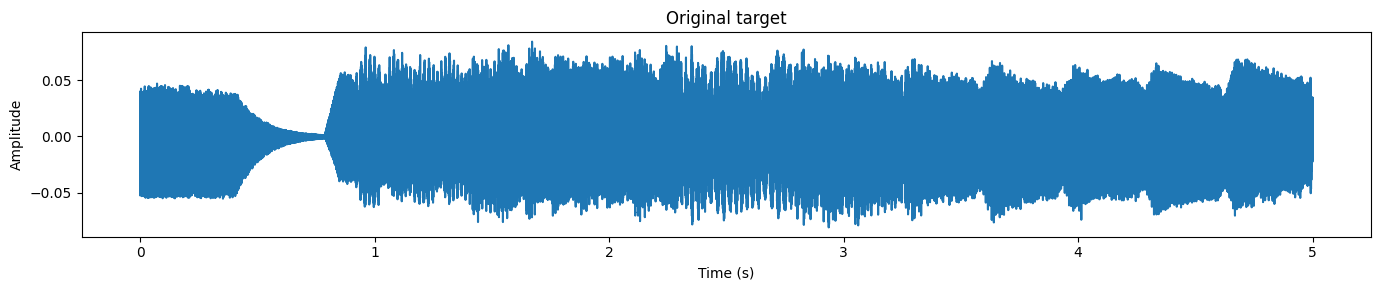

In [9]:
plot_waveform(batch["target_wavs"][0].numpy(), target_sr, title="Original target")

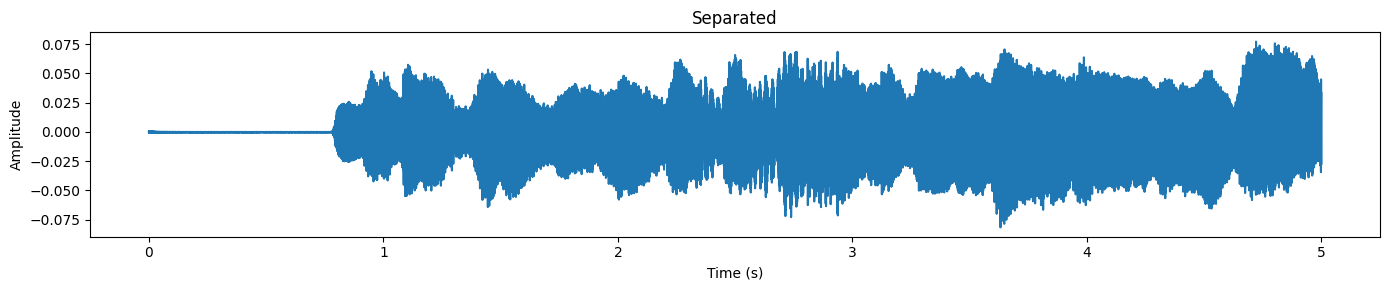

In [10]:
plot_waveform(target_np, target_sr, title="Separated")